In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets

import matplotlib.pyplot as plt
from sklearn.decomposition import  PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from umap import  UMAP
import numpy as np

In [2]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.dmsl import mean_shift_manifold_learning
from src.msde import mean_shift_density_enhancement

In [3]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=None, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=None, download=True)

In [4]:
train_dataset.data = (train_dataset.data.float() / 255.0 - 0.1307) / 0.3081
test_dataset.data = (test_dataset.data.float() / 255.0 - 0.1307) / 0.3083

In [5]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3),
        )

    def forward(self, x):
        x = self.encoder(x)
        return x

In [6]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.decoder(x)
        return x

In [7]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        with torch.no_grad():
            encoder = Encoder()
            sample = torch.randn(1, 1, 28, 28)
            sample = encoder(sample)
            n_flatten = sample.flatten(start_dim=1).shape[1]
          
        self.linear = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(n_flatten, 10),
        )
        self.gate = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(n_flatten, n_flatten),
            nn.Sigmoid(),
        )
        self.weights = None

    def forward(self, x, epoch=0):
        raw = x.flatten(start_dim=1).detach().cpu().numpy()

        if epoch == 0:
            shifted, self.weights, _, _ = mean_shift_manifold_learning(raw, max_iters_shift=500, k=50)
        else:
            shifted, _, _ = mean_shift_manifold_learning(raw, max_iters_shift=500, k=50, weights=self.weights)

        shift = torch.tensor(shifted - raw, dtype=torch.float, device=x.device, requires_grad=False)

        gate = self.gate(x)
        xs = x + (shift * gate).reshape(-1, 64, 1, 1)
        x = self.linear(x)
        return x, xs, gate

In [8]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
        self.classifier = Classifier()

    def forward(self, x, epoch=0):
        x = self.encoder(x)
        pred, shifted, gate = self.classifier(x, epoch)
        x = self.decoder(shifted)

        return pred, shifted, x, gate

In [9]:
def train(model, device, epochs=50):
    history = []
    gates = []

    model.to(device)
    data = train_dataset.data.to(device)
    data = data.unsqueeze(1)
    labels = train_dataset.targets.to(device)

    model.train()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.99)
    reconstruction = nn.MSELoss()
    classification = nn.CrossEntropyLoss()
    # optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        optimizer.zero_grad()

        pred, shifted, x, gate = model(data, epoch=epoch)
        loss = classification(pred, labels) + reconstruction(x, data)*0

        loss.backward()
        optimizer.step()

        history.append(loss.item())
        gates.append(gate.flatten().mean().detach().cpu().numpy())
        if epoch % 10 == 0:
            print(f"Epoch {epoch:02d} | Full-Batch Loss: {loss.item():.4f}")

    return history, gates

In [10]:
model = Model().float()
history, gates = train(model, "mps", epochs=100)

Epoch 00 | Full-Batch Loss: 2.3041
Epoch 10 | Full-Batch Loss: 2.3028
Epoch 20 | Full-Batch Loss: 2.2994
Epoch 30 | Full-Batch Loss: 2.2947
Epoch 40 | Full-Batch Loss: 2.2880
Epoch 50 | Full-Batch Loss: 2.2736
Epoch 60 | Full-Batch Loss: 2.2241
Epoch 70 | Full-Batch Loss: 1.9190
Epoch 80 | Full-Batch Loss: 0.8755
Epoch 90 | Full-Batch Loss: 2.2690


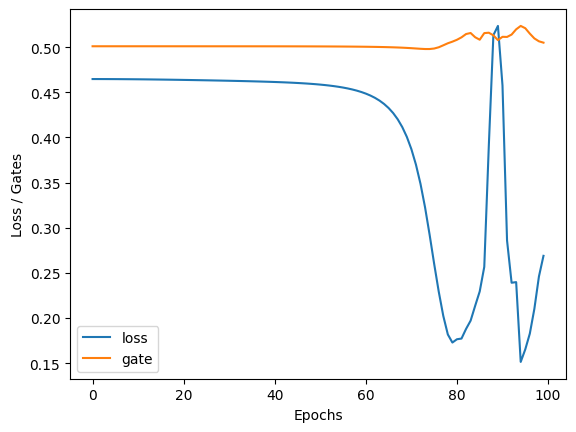

In [11]:
plt.plot(history/np.max(history)*np.max(gates), label="loss")
plt.plot(gates, label="gate")
plt.xlabel('Epochs')
plt.ylabel('Loss / Gates')
plt.legend()
plt.show()

In [12]:
def visualize(model, device):
    model.to(device)

    train_data = train_dataset.data.to(device)
    train_data = train_data.unsqueeze(1)
    test_data = test_dataset.data.to(device)
    test_data = test_data.unsqueeze(1)

    model.eval()
    with torch.no_grad():
        _, train_emb_after, _ = model.classifier(model.encoder(train_data))
        train_emb_before = model.encoder(train_data)
        train_emb_after = train_emb_after.flatten(start_dim=1).cpu().numpy()
        train_emb_before = train_emb_before.flatten(start_dim=1).cpu().numpy()

        _, test_emb_after, _ = model.classifier(model.encoder(test_data))
        test_emb_before = model.encoder(test_data)
        test_emb_after = test_emb_after.flatten(start_dim=1).cpu().numpy()
        test_emb_before = test_emb_before.flatten(start_dim=1).cpu().numpy()

    pca = PCA(n_components=2)
    train_pca_before = pca.fit_transform(train_emb_before)
    train_pca_after = pca.transform(train_emb_after)
    test_pca_before = pca.transform(test_emb_before)
    test_pca_after = pca.transform(test_emb_after)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(train_pca_before[:, 0], train_pca_before[:, 1], c=train_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    plt.title('Train PCA before DMSL')

    plt.subplot(1, 2, 2)
    sc1 = plt.scatter(test_pca_before[:, 0], test_pca_before[:, 1], c=test_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    handles, labels = sc1.legend_elements()
    digit_names = [f"Digit {i}" for i in range(10)]
    plt.legend(handles, digit_names, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Test PCA before DMSL')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(train_pca_after[:, 0], train_pca_after[:, 1], c=train_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    plt.title('Train PCA after DMSL')

    plt.subplot(1, 2, 2)
    sc1 = plt.scatter(test_pca_after[:, 0], test_pca_after[:, 1], c=test_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    handles, labels = sc1.legend_elements()
    digit_names = [f"Digit {i}" for i in range(10)]
    plt.legend(handles, digit_names, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Test PCA after DMSL')

    plt.tight_layout()
    plt.show()

    umap = UMAP(n_components=2)
    train_umap_before = umap.fit_transform(train_emb_before)
    train_umap_after = umap.transform(train_emb_after)
    test_umap_before = umap.transform(test_emb_before)
    test_umap_after = umap.transform(test_emb_after)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(train_umap_before[:, 0], train_umap_before[:, 1], c=train_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    plt.title('Train UMAP before DMSL')

    plt.subplot(1, 2, 2)
    sc2 = plt.scatter(test_umap_before[:, 0], test_umap_before[:, 1], c=test_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    handles, labels = sc2.legend_elements()
    digit_names = [f"Digit {i}" for i in range(10)]
    plt.legend(handles, digit_names, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Test UMAP before DMSL')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(train_umap_after[:, 0], train_umap_after[:, 1], c=train_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    plt.title('Train UMAP after DMSL')

    plt.subplot(1, 2, 2)
    sc2 = plt.scatter(test_umap_after[:, 0], test_umap_after[:, 1], c=test_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    handles, labels = sc2.legend_elements()
    digit_names = [f"Digit {i}" for i in range(10)]
    plt.legend(handles, digit_names, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Test UMAP after DMSL')

    plt.tight_layout()
    plt.show()

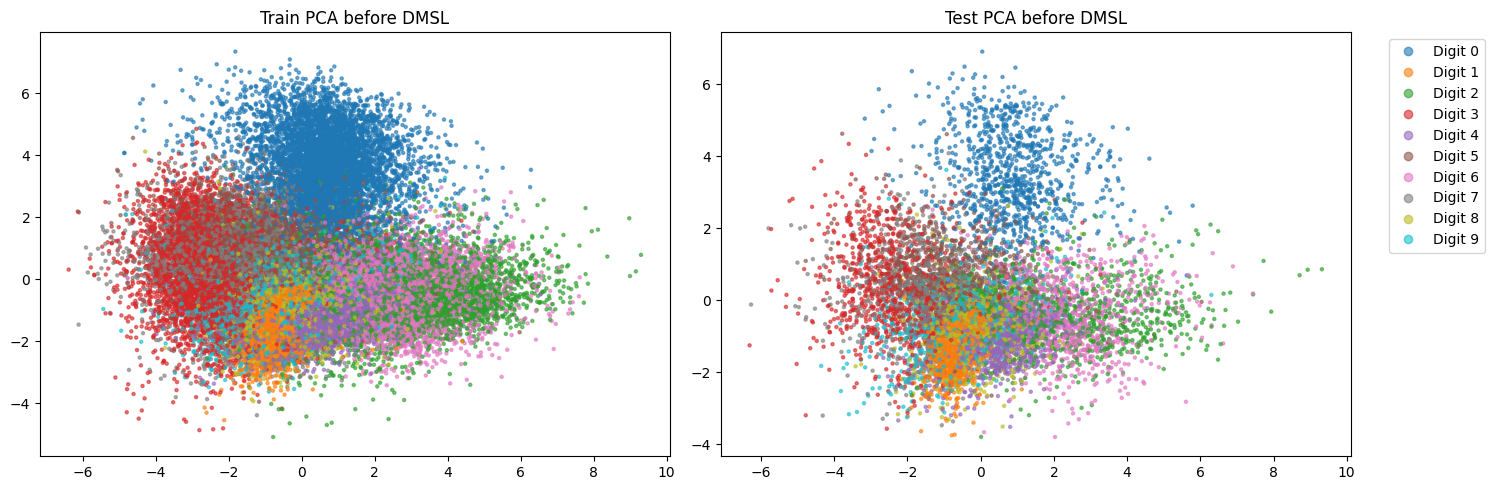

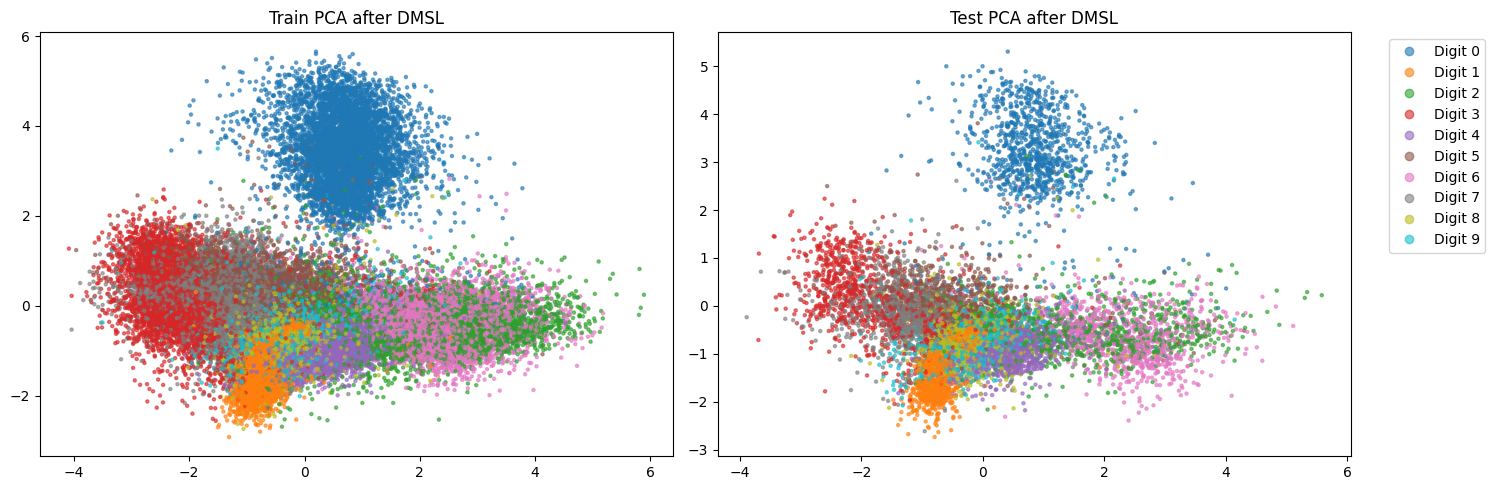

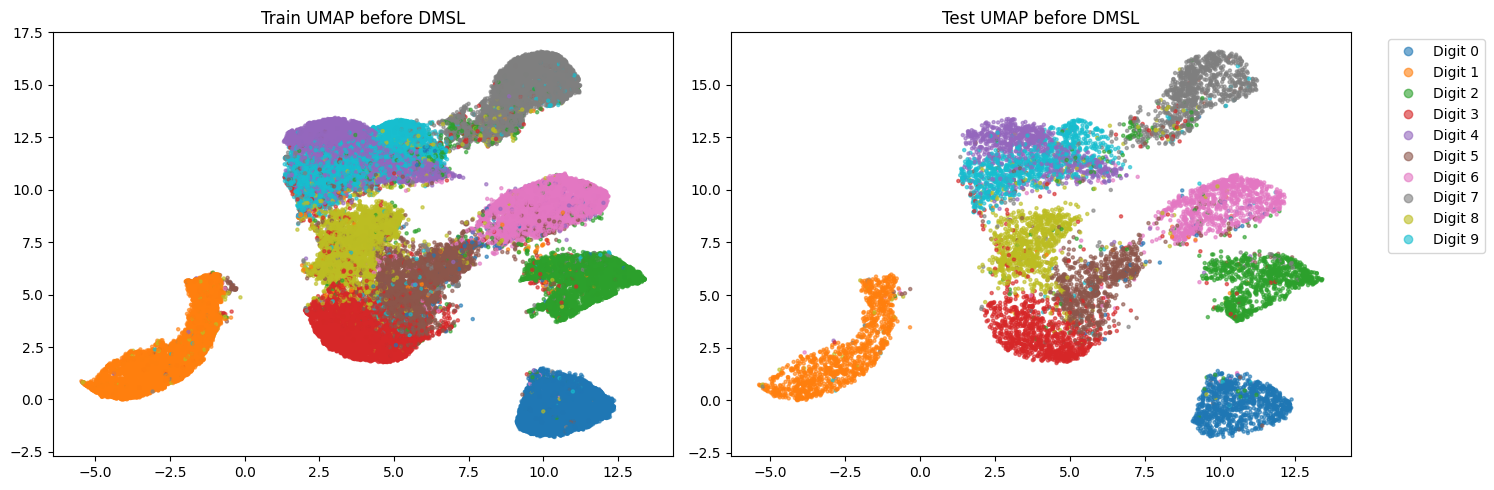

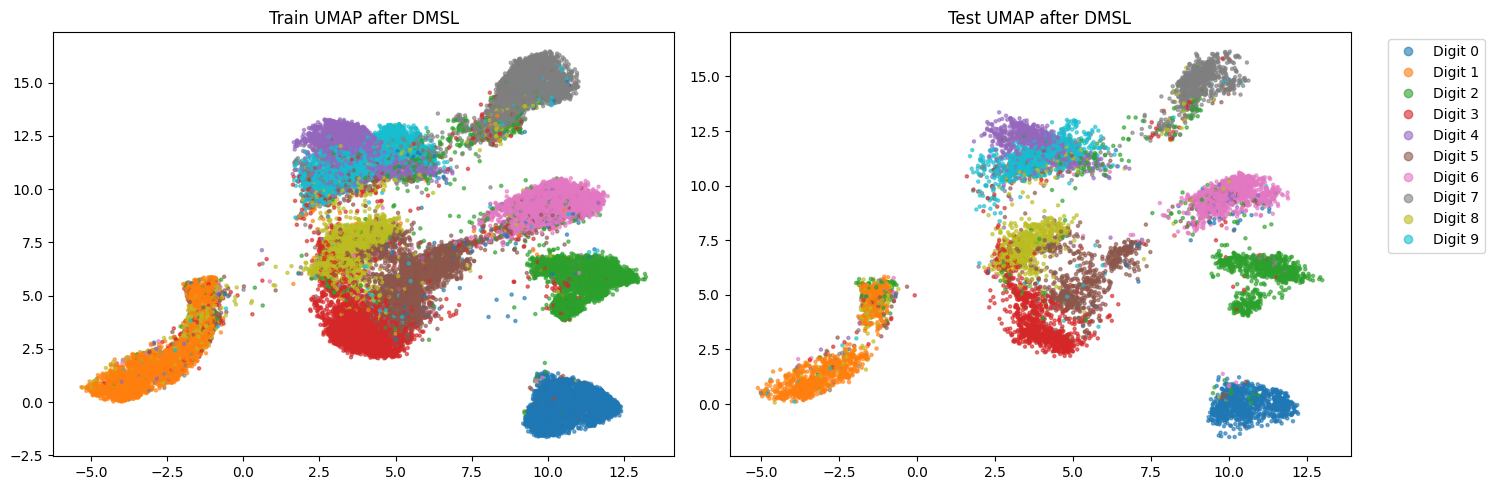

In [13]:
visualize(model, "mps")

In [14]:
model.eval()
with torch.no_grad():
    pred, _, _, _ = model(test_dataset.data.to("mps").unsqueeze(1))

score = accuracy_score(test_dataset.targets, np.argmax(pred.cpu().numpy(), axis=1))
print(score)

0.6838
